In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import pandas as pd
from scipy import interpolate

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

# Constants

In [3]:
# List of atmoic numbers
A_dict = {'H' : 1.00797 ,
'He' : 4.00260 ,
'Li' : 6.941 ,
'Be' : 9.01218 ,
'B' : 10.81 ,
'C' : 12.011 ,
'N' : 14.0067 ,
'O' : 15.994 ,
'F' : 18.9994 ,
'Ne' : 20.179 ,
'Na' : 22.98977 ,
'Mg' : 24.305 ,
'Al' : 26.98154 ,
'Si' : 28.0855 ,
'P' : 30.97376 ,
'S' : 32.06 ,
'Cl' : 35.453 ,
'A' : 39.948 ,
'K' : 39.0983 ,
'Ca' : 40.08 ,
'Sc' : 44.9559 ,
'Ti' : 47.90 ,
'V' : 50.9415 ,
'Te' : 51.996 ,
'Mn' : 54.9380 ,
'Fe' : 55.847 ,
'Co' : 58.70 ,
'Ni' : 58.9332 ,
'Cu' : 63.546 ,
'Zn' : 65.38,
}

In [4]:
# Significance levels
# Sigma values taken from Gehrels 1986
cdf_1sig = 0.8413
cdf_2sig = 0.9772
cdf_3sig = 0.9987

In [5]:
# Boltzmann constant, adjusted to use km instead of m
k_B = 1.380649e-29
# Mass of hydrogen atom
amu = 1.66054e-27

# Functions

In [6]:
def gen_b(logT, b_NT, A):
    
    return np.sqrt((2*k_B*10**logT/(A*amu)) + b_NT**2)

In [7]:
def log_prior(params):

    # Grid parameters being varied
    logT, b_NT = params
    
    # Avoid edges?
    if 4<logT<6 and 0<b_NT<50:
        # Convert to linear T, then take natural log
        return np.log(10**logT)
    return -np.inf

In [8]:
def log_likelihood(params, b_list):
    
    logT, b_NT = params

    #print(logT, b_NT)
    
    ll = 0
    
    for i in range(len(b_list)):
        
        ybar = gen_b(logT, b_NT, A_dict[b_list[i][1]])
        y = b_list[i][2]
        dy = b_list[i][3]
        
        ll += -.5*(y-ybar)**2/dy**2
            
    return ll

In [9]:
def log_probability(params, b_list):
        
    lp = log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, b_list)

In [10]:
gen_b(4., 0, A_dict['H'])

12.844232700646511

In [11]:
gen_b(4, 0, A_dict['C'])

3.7208519053703197

In [12]:
gen_b(4., 0, A_dict['Si'])

2.433273287255247

In [13]:
gen_b(5, 0, A_dict['Mg'])

8.271497744829851

In [14]:
gen_b(4, 0, A_dict['N'])

3.445593622658098

In [15]:
gen_b(4.8, 16, A_dict['O'])

17.933222075561797

In [16]:
gen_b(4, 0, A_dict['Si'])

2.433273287255247

# z=0.67

## c1

### c1H

In [239]:
b_list = [[['HI', 'H', 36, 2],
          ['OIII', 'O', 34, 2],
          ['CIII', 'C', 31, 2],
          ['CIV', 'C', 33, 5]
          ]]

In [240]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [241]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [244]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [245]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

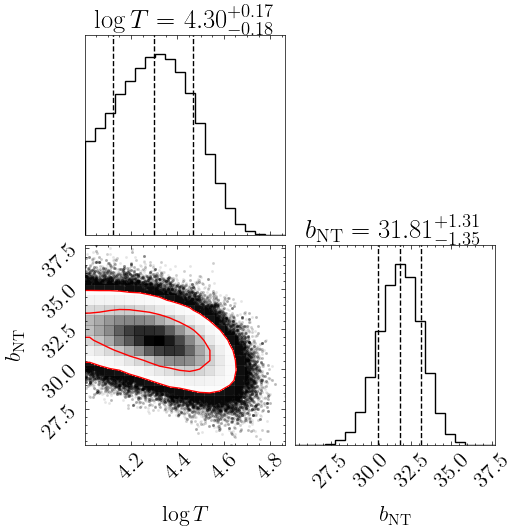

In [246]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [247]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.001245407193947, 4.712425940695306)

### c1L

In [27]:
b_list = [[
          ['OIV', 'O', 30, 2],
          ['OVI', 'O', 32, 3]
          ]]

In [28]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [29]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [30]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:09<00:00, 504.02it/s]


State([[5.98249168e+00 4.64407697e+00]
 [5.93090759e+00 9.44362567e+00]
 [5.91485710e+00 1.43059815e+01]
 [5.75986802e+00 8.94979290e+00]
 [5.18584324e+00 2.68357467e+01]
 [5.43933491e+00 2.16356845e+01]
 [5.57873350e+00 2.16403277e+01]
 [5.94424788e+00 1.44131535e+01]
 [5.91638296e+00 7.38738817e+00]
 [5.68151879e+00 2.24254545e+01]
 [5.68271302e+00 1.90486155e+01]
 [5.48875941e+00 2.45324303e+01]
 [5.73521999e+00 1.82276394e+01]
 [5.92556782e+00 4.69496783e+00]
 [5.64463381e+00 2.00020473e+01]
 [5.55083263e+00 2.18295258e+01]
 [5.67520468e+00 2.33172051e+01]
 [5.96017842e+00 9.81507294e+00]
 [5.02559047e+00 2.77832944e+01]
 [5.97493003e+00 8.63783450e+00]
 [5.92996847e+00 4.90588637e-01]
 [5.93066349e+00 6.08915115e+00]
 [5.87724942e+00 9.86956616e+00]
 [5.94026470e+00 1.00490741e+01]
 [5.62250122e+00 2.08973218e+01]
 [5.80070917e+00 1.47520174e+01]
 [5.88981064e+00 9.32969905e+00]
 [5.94277308e+00 6.01168291e+00]
 [5.30006141e+00 2.82619028e+01]
 [4.80937834e+00 2.80078220e+01]
 [5.

In [31]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

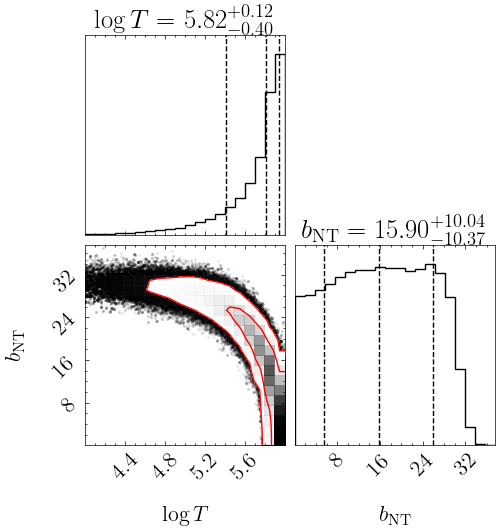

In [32]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

(array([ 54792.,  58266.,  61814.,  66320.,  74355.,  85032., 105743.,
        141333., 153539.,  98806.]),
 array([ 10003.2299565 , 109002.7615557 , 208002.2931549 , 307001.82475411,
        406001.35635331, 505000.88795251, 604000.41955172, 702999.95115092,
        801999.48275012, 900999.01434932, 999998.54594853]),
 <BarContainer object of 10 artists>)

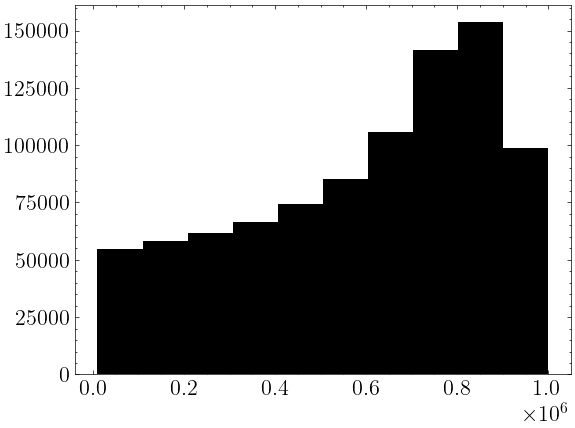

In [33]:
plt.hist(10**flat_samples['logT'])

In [34]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.069670293484817, 5.999182865357982)

In [35]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

33.235700031194284

# z=1.04

## c1

### c1H

In [39]:
b_list = [[['HI', 'H', 19, 1],
           ['CIV', 'C', 6.7, 0.3],
           ]]

In [40]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [41]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [44]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [45]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

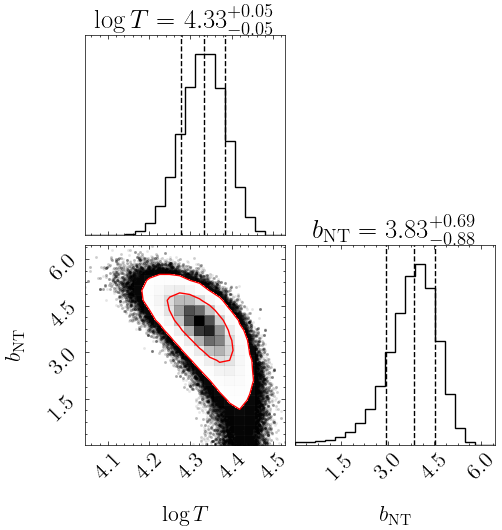

In [46]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [47]:
np.percentile(flat_samples['logT'],100*(1-cdf_3sig)), np.percentile(flat_samples['logT'],100*cdf_3sig)

(4.1541669568563035, 4.473937007145371)

### c1L

In [29]:
b_list = [[['OV', 'O', 23, 2],
           ]]

In [30]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [31]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [34]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [35]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

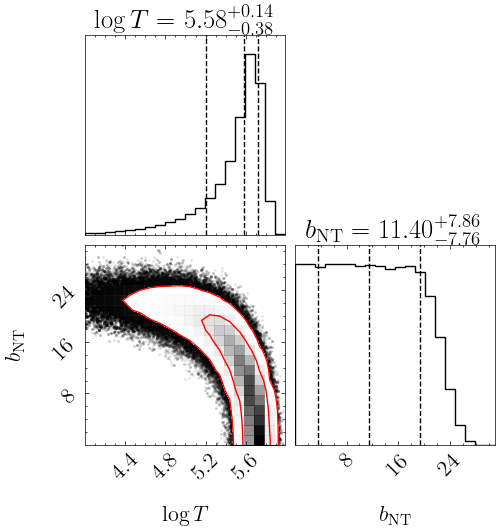

In [36]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [38]:
np.percentile(flat_samples['logT'],100*cdf_3sig), np.percentile(flat_samples['b_NT'],100*cdf_3sig)

(5.885385147345337, 26.500169230689387)

## c2

In [48]:
b_list = [[['HI', 'H', 10, 2],
           ['CIV', 'C', 6.3, 0.4],
           ]]

In [49]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [50]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [52]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [53]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

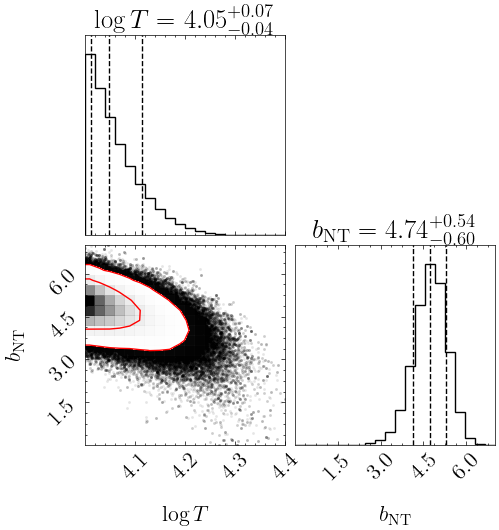

In [54]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [56]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.289568397277587

## c3

### c3H

In [57]:
b_list = [[['HI', 'H', 14, 3],
          ['CIV', 'C', 10, 1]]]

In [58]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [59]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [63]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [64]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

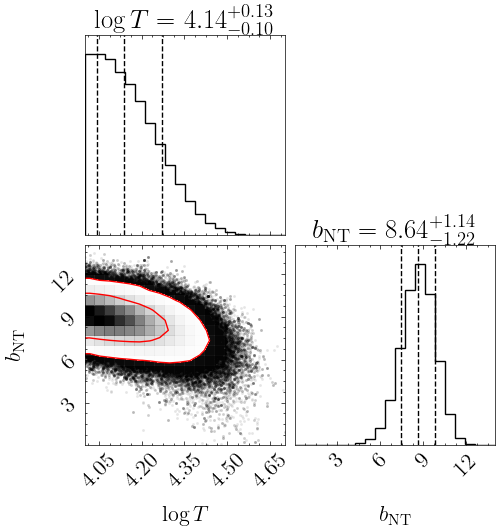

In [65]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [66]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.532791134023759

### c3L

In [67]:
b_list = [[['OV', 'O', 26, 3]]]

In [68]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [69]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [75]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [71]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

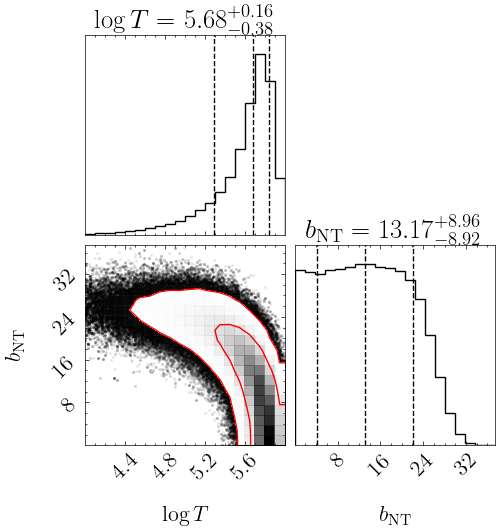

In [72]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [73]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

5.994272529247227

In [74]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

31.75264001425646

## c4

In [83]:
b_list = [[['HI', 'H', 21, 5],
          ['CIV', 'C', 8.3, 0.6]]]

In [84]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [85]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [88]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [89]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

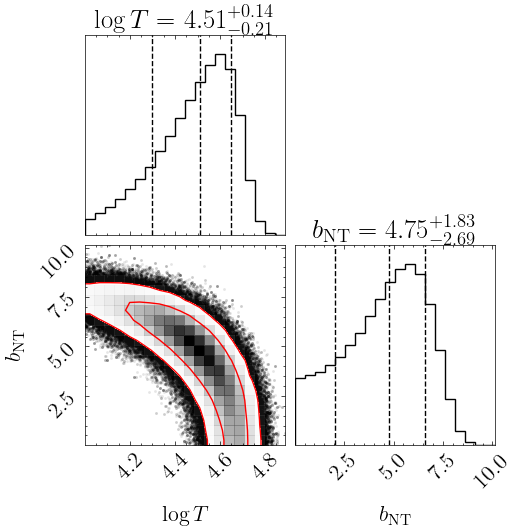

In [90]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [91]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

8.677502824362456

In [92]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.7983999710083465

# z=1.09

## c1

### c1H

In [114]:
b_list = [[['HI', 'H', 21, 3],
          ['CIV', 'C', 18.3, 0.3],
          ['NIV', 'N', 12, 6],
          ['OIII', 'O', 25, 4]
          ]]

In [115]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(400, 2)
nwalkers, ndim = pos.shape

In [116]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [118]:
#sampler.run_mcmc(pos, 8000, progress=True)

In [119]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

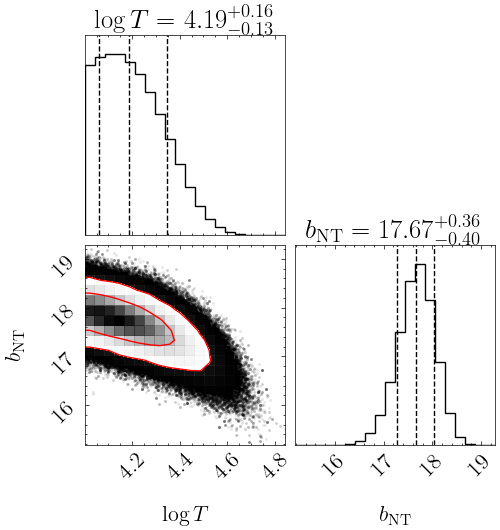

In [120]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [121]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.624341019870603

### c1L

In [106]:
b_list = [[['OIV', 'O', 23, 1],
          ['OV', 'O', 26, 2]]]

In [107]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [108]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [110]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [111]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

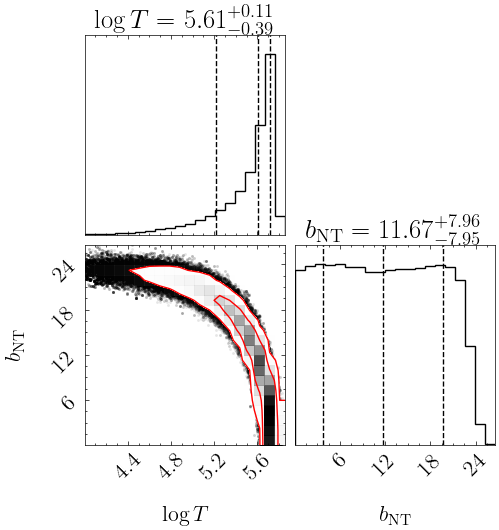

In [112]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [113]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.068017676673675, 5.8048376209588035)

In [114]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

24.695267905005345

# z=1.16

## c1H

In [134]:
b_list = [[['HI', 'H', 19, 3],
          ['HeI', 'He', 12, 1],
          #['CIII', 'C', 11.0, 0.4],
          ['CIV', 'C', 11.0, 0.4],
          ['OIII', 'O', 14, 3],
          ['OIV', 'O', 16, 2],
          ['OV', 'O', 10, 3],
          ['SiIII', 'Si', 11, 2]]]

In [135]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [136]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [139]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [140]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

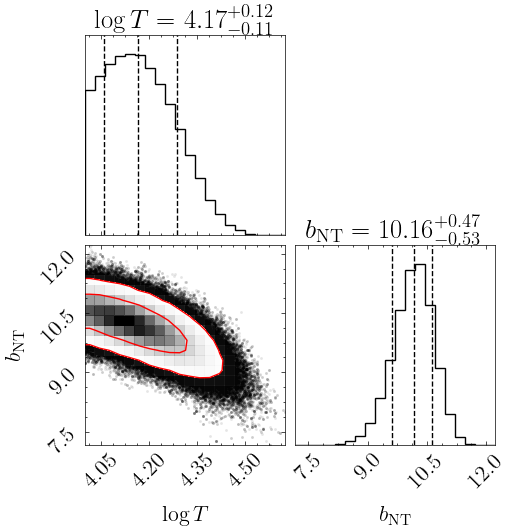

In [141]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [142]:
np.median(flat_samples['b_NT'])-np.percentile(flat_samples['b_NT'], 100*(1-cdf_1sig))

0.53718611584158

In [143]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.502720057379096

## c1L

In [164]:
b_list = [[
          ['OVI', 'O', 45, 17]]]

In [155]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [156]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [159]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [160]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

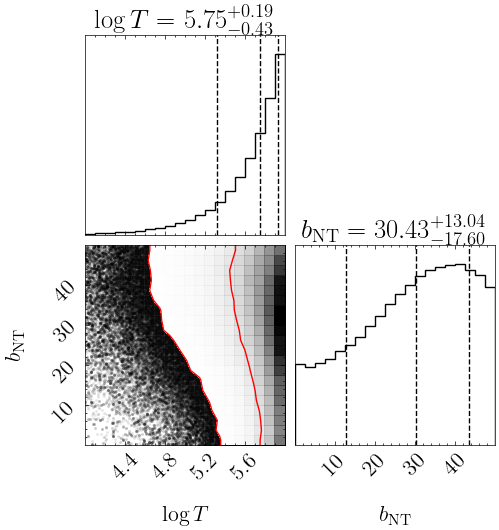

In [161]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [162]:
np.median(flat_samples['b_NT'])-np.percentile(flat_samples['b_NT'], 100*(1-cdf_1sig))

17.686598584966326

In [163]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

5.999503035795597

## c2

In [145]:
b_list = [[['HI', 'H', 32, 3],
           ['CIV', 'C', 27, 3],
          ['OIV', 'O', 27, 7],
          ['OV', 'O', 28, 3]]]

In [146]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [147]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [150]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [151]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

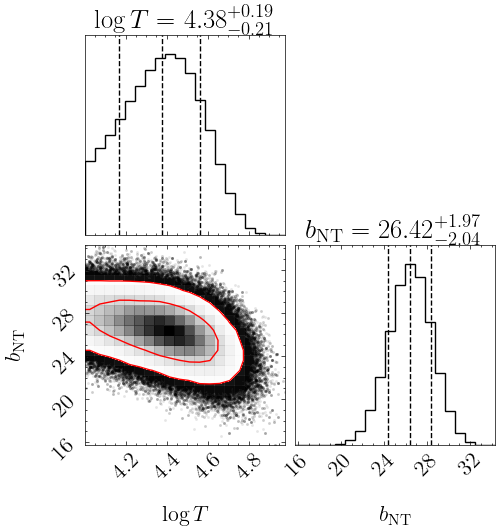

In [152]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [153]:
np.percentile(flat_samples['logT'], 100*cdf_3sig), np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

(4.835081307669842, 32.156773929364824)

# z=1.22

## c1

In [165]:
b_list = [[['HI', 'H', 26, 5],
           ['CIV', 'C', 16, 3],
          ['OVI', 'O', 21, 2]]]

In [166]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [167]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [170]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [171]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

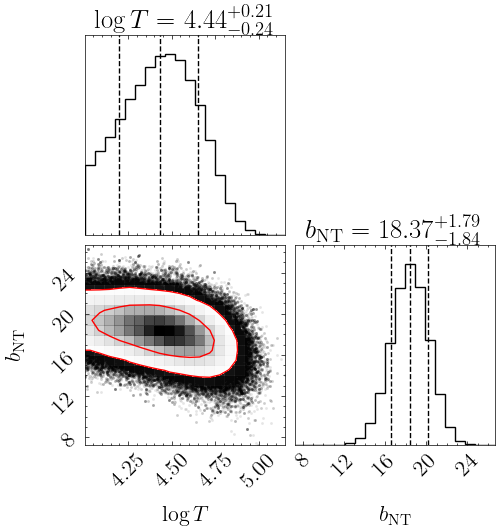

In [172]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [173]:
np.percentile(flat_samples['logT'], 100*cdf_3sig), np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

(4.959527870467884, 23.693784067971258)

# z=1.26

## c1

In [174]:
b_list = [[['HI', 'H', 22, 2],
          ['CIV', 'C', 6.6, 0.6],
          ]]

In [175]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [176]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [178]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [179]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

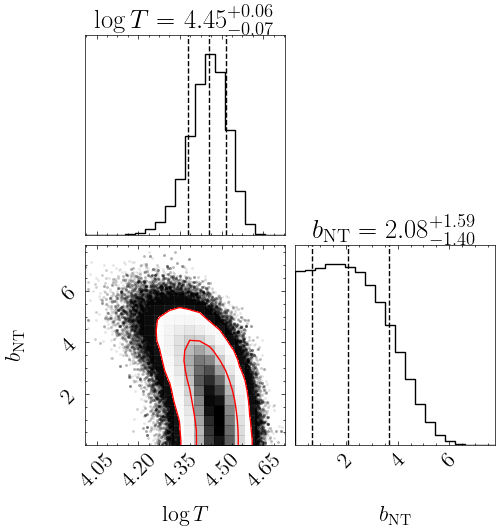

In [180]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [181]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.1716522137599705, 4.625962745654395)

In [182]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

6.144952785942156

# z=1.27

## c1

## c2

### Single phase

In [190]:
b_list = [[['HI', 'H', 33, 10],
          ['CIV', 'C', 9.8, 0.3],
          ['OIV', 'O', 12, 2],
          ]]

In [191]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [192]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [194]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [195]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

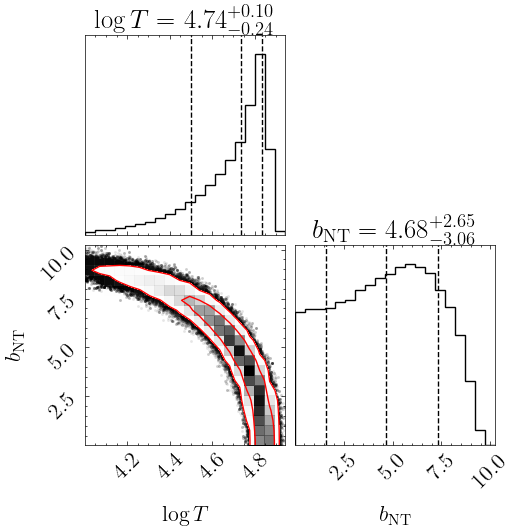

In [196]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [198]:
np.percentile(flat_samples['logT'], 100*cdf_3sig), np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

(4.905634948869444, 9.481834989138214)

# DRAFT

## z=0.72

In [69]:
b_list = [[['HI', 'H', 25.6, 0.4],
          ['CIII', 'C', 15, 4],
          ['OIII', 'O', 12, 2]]]

In [70]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [71]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [72]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:13<00:00, 378.65it/s]


State([[ 4.5384403   8.09929585]
 [ 4.47312911 12.56506458]
 [ 4.51935019  9.9915456 ]
 [ 4.43163142 15.65060414]
 [ 4.52375086  9.37540148]
 [ 4.54954478  6.62458899]
 [ 4.52685679 10.13970275]
 [ 4.42873199 14.08212653]
 [ 4.50605638 12.29829318]
 [ 4.50825934 10.95642096]
 [ 4.52653629 10.0437353 ]
 [ 4.43088461 14.06331714]
 [ 4.52991303 10.05491318]
 [ 4.5366154   8.2728032 ]
 [ 4.57220497  8.25733952]
 [ 4.47898707 12.46445221]
 [ 4.57009848  8.66609242]
 [ 4.50306259 11.53717785]
 [ 4.36597978 15.86877089]
 [ 4.56793488  9.68422604]
 [ 4.45187513 13.86462879]
 [ 4.56351901  5.3446461 ]
 [ 4.59466794  3.46409942]
 [ 4.53785633  9.65510504]
 [ 4.55211141  8.05027689]
 [ 4.49100075 11.93868292]
 [ 4.54138785 10.3322841 ]
 [ 4.54959999  9.2107803 ]
 [ 4.42833962 14.57471485]
 [ 4.51295023 12.04145711]
 [ 4.59385652  7.83400509]
 [ 4.46092935 12.78548227]
 [ 4.5263072  12.37414796]
 [ 4.48133168 13.77105522]
 [ 4.49751563 10.66109777]
 [ 4.53237196  9.36835803]
 [ 4.53007861 10.24665

In [73]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

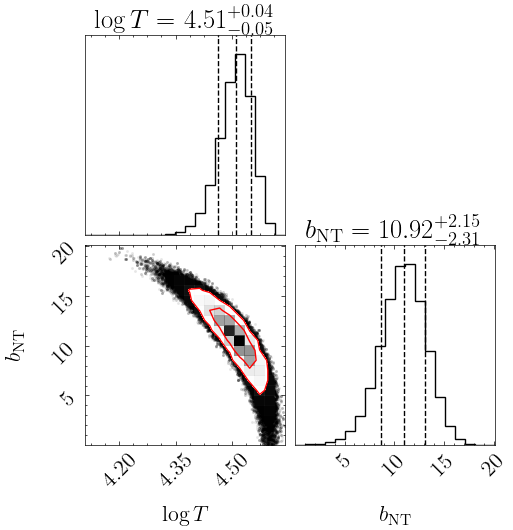

In [74]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Predicted linewidths

In [75]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

12.821218751413966

In [76]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

12.567972555170432

In [77]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

12.375375197197565

In [78]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

12.088713599866455

In [79]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

11.898696060874855

In [80]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

11.805498059645785

In [81]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

11.77212289470581

In [82]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

11.670068905881259

In [83]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

11.358898777000608